<a href="https://colab.research.google.com/github/rikharhm0208-coder/PROJECT_KOMPUTASI_KEUANGAN/blob/main/SIMULASI_MONTE_CARLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

/tmp/ipykernel_2503/4262236744.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="1y")
[*********************100%***********************]  1 of 1 completed


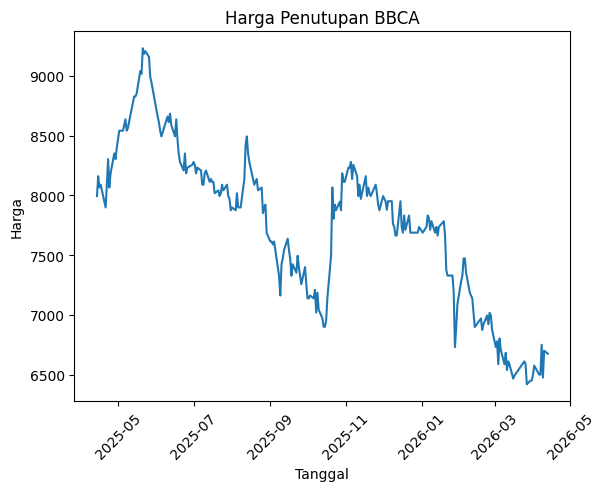

In [ ]:
# ==============================
# Ambil Data BBCA 1 Tahun
# ==============================

ticker = "BBCA.JK"
data = yf.download(ticker, period="1y")

# Jika kolom berbentuk MultiIndex (ada level ticker), ambil level pertama saja
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Reset index supaya Date jadi kolom biasa
data = data.reset_index()

# Pakai harga penutupan
prices = data['Close']

# Perhitungan Log Return
log_return = np.log(prices / prices.shift(1)).dropna()

# Plot harga penutupan saham BBCA
plt.figure()
plt.plot(data['Date'], prices)
plt.title("Harga Penutupan BBCA")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ==============================
# PARAMETER SIMULASI
# ==============================

T = 1          # horizon waktu (1 tahun)
L = 252        # jumlah langkah waktu (hari trading)
dt = T / L     # panjang interval waktu
S0 = prices.iloc[-1].item() # Harga awal simulasi

# ==============================
# Hitung Variansi log return
# ==============================
var_log = log_return.var()

# Estimasi sigma sesuai formula
sigma = (1/np.sqrt(dt)) * np.sqrt(var_log)

# ==============================
# Hitung mean log return
# ==============================
mean_log = log_return.mean()

# Estimasi mu sesuai formula
mu = (1/dt)*mean_log + 0.5*sigma**2

print("S0: ", S0)
print("mu: ", mu)
print("sigma: ", sigma)

S0:  6675.0
mu:  -0.157067753444603
sigma:  0.2668078060145472


In [ ]:
import numpy as np

# ==============================
# PARAMETER
# ==============================
S0 = 6675
sigma = 0.2668
r = 0.0475
T = 1
K = 6500
M = 100000

# ==============================
# MONTE CARLO
# ==============================
Z = np.random.normal(0,1,M)

ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

# Call
V_call = np.exp(-r*T) * np.maximum(ST - K, 0)

# Put
V_put = np.exp(-r*T) * np.maximum(K - ST, 0)

# Estimasi harga
C = np.mean(V_call)
P = np.mean(V_put)

# Standard error
SE_call = np.std(V_call)/np.sqrt(M)
SE_put = np.std(V_put)/np.sqrt(M)

print("Call Price:", C)
print("Put Price:", P)
print("SE Call:", SE_call)
print("SE Put:", SE_put)

Call Price: 951.2707423945312
Put Price: 471.0219872869519
SE Call: 4.362497074272734
SE Put: 2.270474666767844


In [ ]:
CI_call = (C - 1.96*SE_call, C + 1.96*SE_call)
CI_put = (P - 1.96*SE_put, P + 1.96*SE_put)

print("CI Call:", CI_call)
print("CI Put:", CI_put)

CI Call: (np.float64(942.7202481289567), np.float64(959.8212366601058))
CI Put: (np.float64(466.57185694008695), np.float64(475.4721176338169))


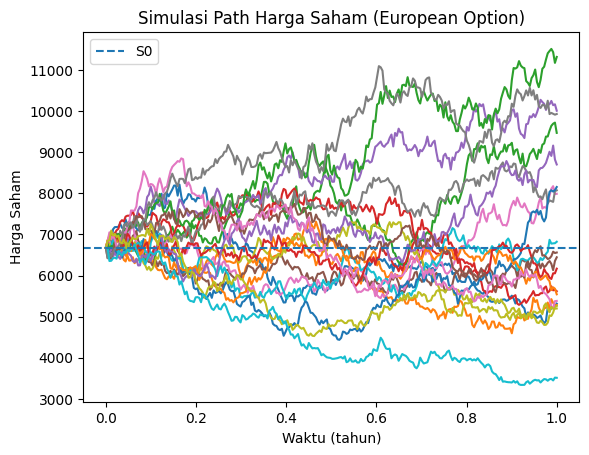

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# PARAMETER
# ==============================
S0 = 6675
sigma = 0.2668
r = 0.0475
T = 1
N = 252
dt = T / N

num_paths = 20

time = np.linspace(0, T, N)

plt.figure()

for i in range(num_paths):
    S = np.zeros(N)
    S[0] = S0

    for t in range(1, N):
        Z = np.random.normal()
        S[t] = S[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

    plt.plot(time, S)

# garis S0
plt.axhline(S0, linestyle='--', label='S0')

plt.title("Simulasi Path Harga Saham (European Option)")
plt.xlabel("Waktu (tahun)")
plt.ylabel("Harga Saham")
plt.legend()
plt.show()

In [ ]:
import numpy as np

# ==============================
# PARAMETER
# ==============================
S0 = 6675
sigma = 0.2668
r = 0.0475
T = 1
K = 6500

M = 50000     # jumlah simulasi
N = 252       # time steps
dt = T / N

# Barrier
B_down = 6000
B_up = 7200

# ==============================
# SIMULASI PATH (VECTORIZE)
# ==============================

Z = np.random.normal(0, 1, (M, N))

drift = (r - 0.5 * sigma**2) * dt
diffusion = sigma * np.sqrt(dt) * Z

log_S = np.cumsum(drift + diffusion, axis=1)
S_paths = S0 * np.exp(log_S)

# ==============================
# CEK BARRIER
# ==============================
hit_down = np.any(S_paths <= B_down, axis=1)
hit_up = np.any(S_paths >= B_up, axis=1)

ST = S_paths[:, -1]

# ==============================
# PAYOFF
# ==============================
call_payoff = np.maximum(ST - K, 0)
put_payoff  = np.maximum(K - ST, 0)

disc = np.exp(-r*T)

# ===== CALL =====
DO_call = disc * np.where(hit_down, 0, call_payoff)
DI_call = disc * np.where(hit_down, call_payoff, 0)
UO_call = disc * np.where(hit_up, 0, call_payoff)
UI_call = disc * np.where(hit_up, call_payoff, 0)

# ===== PUT =====
DO_put = disc * np.where(hit_down, 0, put_payoff)
DI_put = disc * np.where(hit_down, put_payoff, 0)
UO_put = disc * np.where(hit_up, 0, put_payoff)
UI_put = disc * np.where(hit_up, put_payoff, 0)

# ==============================
# STATISTIK
# ==============================
def stats(x):
    mean = np.mean(x)
    se = np.std(x)/np.sqrt(M)
    ci = (mean - 1.96*se, mean + 1.96*se)
    return mean, se, ci

results = {
    "DO Call": stats(DO_call),
    "DI Call": stats(DI_call),
    "UO Call": stats(UO_call),
    "UI Call": stats(UI_call),
    "DO Put" : stats(DO_put),
    "DI Put" : stats(DI_put),
    "UO Put" : stats(UO_put),
    "UI Put" : stats(UI_put),
}

# ==============================
# OUTPUT
# ==============================
print("===== BARRIER OPTIONS (CALL & PUT) =====\n")

for k, v in results.items():
    print(f"{k}:")
    print("  Price:", v[0])
    print("  SE   :", v[1])
    print("  CI   :", v[2])
    print()

# ==============================
# VALIDASI (WAJIB)
# ==============================
print("=== VALIDATION ===")
print("DO Call + DI Call ≈ European Call")
print(results["DO Call"][0] + results["DI Call"][0])

print("UO Call + UI Call ≈ European Call")
print(results["UO Call"][0] + results["UI Call"][0])

print("DO Put + DI Put ≈ European Put")
print(results["DO Put"][0] + results["DI Put"][0])

print("UO Put + UI Put ≈ European Put")
print(results["UO Put"][0] + results["UI Put"][0])

===== BARRIER OPTIONS (CALL & PUT) =====

DO Call:
  Price: 695.958037650184
  SE   : 5.905343322906504
  CI   : (np.float64(684.3835647372872), np.float64(707.5325105630808))

DI Call:
  Price: 245.5037224124972
  SE   : 2.9852085389284415
  CI   : (np.float64(239.65271367619746), np.float64(251.35473114879696))

UO Call:
  Price: 4.462228632383667
  SE   : 0.17812439301087585
  CI   : (np.float64(4.1131048220823505), np.float64(4.811352442684983))

UI Call:
  Price: 936.9995314302973
  SE   : 6.089799189872248
  CI   : (np.float64(925.0635250181477), np.float64(948.9355378424469))

DO Put:
  Price: 2.9519580786481594
  SE   : 0.12201230283660436
  CI   : (np.float64(2.7128139650884147), np.float64(3.191102192207904))

DI Put:
  Price: 471.44143745515527
  SE   : 3.2361743857153726
  CI   : (np.float64(465.09853565915313), np.float64(477.7843392511574))

UO Put:
  Price: 284.4048022965595
  SE   : 2.8763282265560597
  CI   : (np.float64(278.7671989725096), np.float64(290.0424056206094

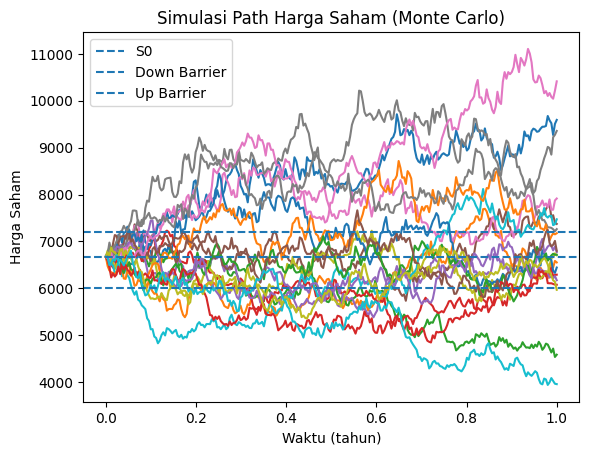

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# PARAMETER
# ==============================
S0 = 6675
sigma = 0.2668
r = 0.0475
T = 1
N = 252
dt = T / N

num_paths = 20   # jumlah path yang ditampilkan

# Barrier (opsional)
B_down = 6000
B_up = 7200

# ==============================
# SIMULASI PATH
# ==============================
time = np.linspace(0, T, N)

plt.figure()

for i in range(num_paths):
    S = np.zeros(N)
    S[0] = S0

    for t in range(1, N):
        Z = np.random.normal()
        S[t] = S[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

    plt.plot(time, S)

# ==============================
# PLOT BARRIER
# ==============================
plt.axhline(S0, linestyle='--', label='S0')

# Barrier lines
plt.axhline(B_down, linestyle='--', label='Down Barrier')
plt.axhline(B_up, linestyle='--', label='Up Barrier')

# ==============================
# LABEL
# ==============================
plt.title("Simulasi Path Harga Saham (Monte Carlo)")
plt.xlabel("Waktu (tahun)")
plt.ylabel("Harga Saham")
plt.legend()
plt.show()